## Resonance Curves

For a driven damped oscillator, the steady-state oscillation amplitude is

$$ A(\omega)=\frac{f_0}{\sqrt{(\omega_0^2-\omega^2)^2+4\beta^2\omega^2}} $$

where $\omega_0$ is the natural frequency of the system and $\beta$ controls the damping strength.

The plot below shows how the response amplitude varies with driving frequency for several different damping ratios $\beta/\omega_0$

For weak damping, the oscillator exhibits a pronounced resonance peak near its natural frequency. As the damping increases, the peak becomes lower and broader, indicating that energy supplied by the external force is dissipated more efficiently.

When

$$ \beta > \frac{\omega_0}{\sqrt{2}} $$

the resonance peak disappears entirely, and the amplitude decreases smoothly with increasing driving frequency.

The undamped case $(\beta=0)$ is shown separately. In this idealized limit the amplitude becomes singular at

$$ \omega=\omega_0 $$

demonstrating the mathematical divergence associated with perfect resonance.

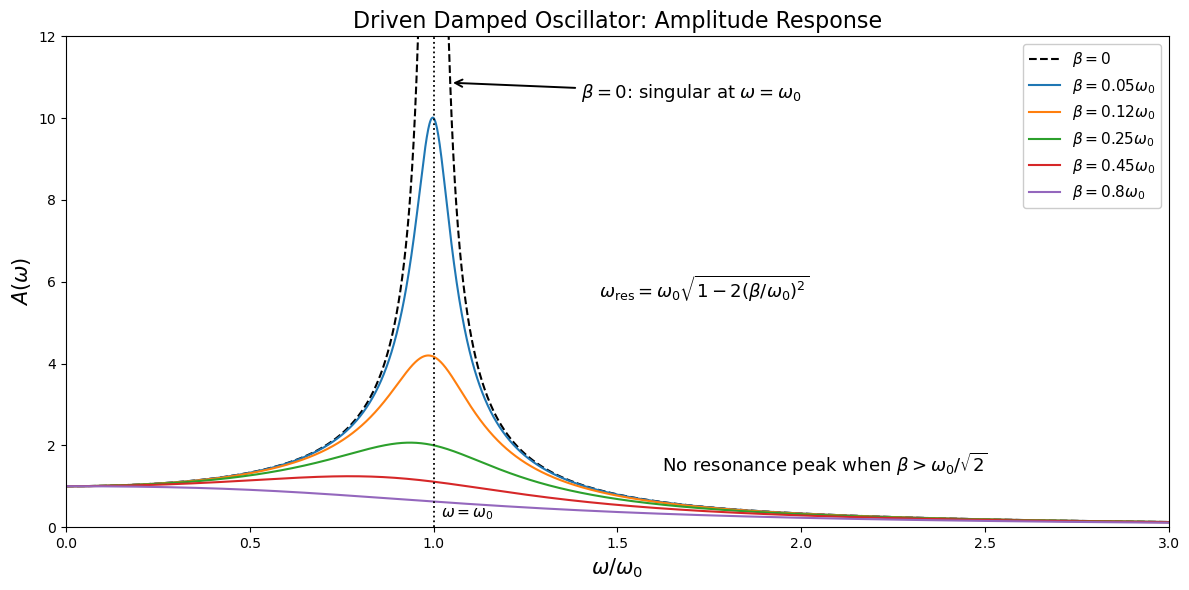

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Normalized parameters
omega0 = 1.0
f0 = 1.0

# Frequency ratio: x = omega / omega0
x = np.linspace(0, 3, 3000)
omega = x * omega0

# Damping ratios: beta / omega0
beta_ratios = [0, 0.05, 0.12, 0.25, 0.45, 0.8]

plt.figure(figsize=(12, 6))

for beta_ratio in beta_ratios:
    beta = beta_ratio * omega0

    if beta_ratio == 0:
        # Avoid the singularity at omega = omega0
        mask = np.abs(x - 1) > 0.01

        A = f0 / np.abs(omega0**2 - omega[mask]**2)

        plt.plot(
            x[mask],
            A,
            linewidth=1.5,
            linestyle="--",
            color="black",
            label=r"$\beta=0$"
        )

    else:
        A = f0 / np.sqrt(
            (omega0**2 - omega**2)**2
            + 4 * beta**2 * omega**2
        )

        plt.plot(
            x,
            A,
            linewidth=1.5,
            label=rf"$\beta={beta_ratio}\omega_0$"
        )

# Natural frequency marker
plt.axvline(
    1,
    linestyle=":",
    color="black",
    linewidth=1.3
)

plt.text(
    1.02,
    0.23,
    r"$\omega=\omega_0$",
    fontsize=11
)

# Resonance frequency equation
plt.text(
    1.45,
    5.6,
    r"$\omega_{\mathrm{res}}=\omega_0\sqrt{1-2(\beta/\omega_0)^2}$",
    fontsize=13
)

# Annotation for the undamped singularity
omega_arrow = 1.045
A_arrow = f0 / abs(omega0**2 - omega_arrow**2)

plt.annotate(
    r"$\beta=0$: singular at $\omega=\omega_0$",
    xy=(omega_arrow, A_arrow),
    xytext=(1.4, 10.5),
    arrowprops=dict(
        arrowstyle="->",
        linewidth=1.4
    ),
    fontsize=13
)

plt.text(
    1.62,
    1.35,
    r"No resonance peak when $\beta>\omega_0/\sqrt{2}$",
    fontsize=13
)

plt.xlim(0, 3)
plt.ylim(0, 12)

plt.xlabel(r"$\omega/\omega_0$", fontsize=15)
plt.ylabel(r"$A(\omega)$", fontsize=15)

plt.title(
    "Driven Damped Oscillator: Amplitude Response",
    fontsize=16
)

plt.legend(
    loc="upper right",
    fontsize=11,
    framealpha=1
)

plt.tight_layout()
plt.show()